# Traffic Accident Analysis Notebook

This notebook will run the full accident prediction project once datasets are uploaded.

In [2]:
print('Notebook ready. Upload datasets to begin analysis.')

Notebook ready. Upload datasets to begin analysis.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

In [6]:
from google.colab import files

print("Upload weather_data_large.csv")
files.upload()

print("Upload traffic_data_large.csv")
files.upload()

Upload weather_data_large.csv


Saving weather_data_large.csv to weather_data_large (1).csv
Upload traffic_data_large.csv


Saving traffic_data_large.csv to traffic_data_large.csv


{'traffic_data_large.csv': b'timestamp,vehicle_count\n2025-01-01 00:00:00,10\n2025-01-01 00:01:00,161\n2025-01-01 00:02:00,64\n2025-01-01 00:03:00,71\n2025-01-01 00:04:00,83\n2025-01-01 00:05:00,125\n2025-01-01 00:06:00,105\n2025-01-01 00:07:00,41\n2025-01-01 00:08:00,41\n2025-01-01 00:09:00,145\n2025-01-01 00:10:00,38\n2025-01-01 00:11:00,47\n2025-01-01 00:12:00,156\n2025-01-01 00:13:00,81\n2025-01-01 00:14:00,12\n2025-01-01 00:15:00,136\n2025-01-01 00:16:00,62\n2025-01-01 00:17:00,144\n2025-01-01 00:18:00,181\n2025-01-01 00:19:00,174\n2025-01-01 00:20:00,9\n2025-01-01 00:21:00,102\n2025-01-01 00:22:00,7\n2025-01-01 00:23:00,174\n2025-01-01 00:24:00,161\n2025-01-01 00:25:00,86\n2025-01-01 00:26:00,192\n2025-01-01 00:27:00,106\n2025-01-01 00:28:00,159\n2025-01-01 00:29:00,142\n2025-01-01 00:30:00,11\n2025-01-01 00:31:00,163\n2025-01-01 00:32:00,191\n2025-01-01 00:33:00,108\n2025-01-01 00:34:00,100\n2025-01-01 00:35:00,128\n2025-01-01 00:36:00,69\n2025-01-01 00:37:00,86\n2025-01-01 00:3

In [7]:
weather = pd.read_csv("weather_data_large.csv")
traffic = pd.read_csv("traffic_data_large.csv")

weather['timestamp'] = pd.to_datetime(weather['timestamp'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])

weather.head(), traffic.head()

(            timestamp  rain  visibility
 0 2025-01-01 00:00:00   1.0         474
 1 2025-01-01 00:01:00   2.0         319
 2 2025-01-01 00:02:00   0.0          91
 3 2025-01-01 00:03:00   1.0         289
 4 2025-01-01 00:04:00   0.5         142,
             timestamp  vehicle_count
 0 2025-01-01 00:00:00             10
 1 2025-01-01 00:01:00            161
 2 2025-01-01 00:02:00             64
 3 2025-01-01 00:03:00             71
 4 2025-01-01 00:04:00             83)

In [8]:
df = pd.merge_asof(
    traffic.sort_values("timestamp"),
    weather.sort_values("timestamp"),
    on="timestamp",
    direction="nearest"
)

df.head()

,timestamp,vehicle_count,rain,visibility
0,2025-01-01 00:00:00,10,1.0,474
1,2025-01-01 00:01:00,161,2.0,319
2,2025-01-01 00:02:00,64,0.0,91
3,2025-01-01 00:03:00,71,1.0,289
4,2025-01-01 00:04:00,83,0.5,142


In [9]:
df["is_rain"] = df["rain"].apply(lambda x: 1 if x > 0 else 0)
df["low_visibility"] = df["visibility"].apply(lambda x: 1 if x < 100 else 0)

df["density_level"] = pd.cut(
    df["vehicle_count"],
    bins=[0,20,50,200],
    labels=["Low","Medium","High"]
)

df["risk_score"] = (
    df["vehicle_count"]*0.3 +
    df["is_rain"]*25 +
    df["low_visibility"]*20
)

df.head()

,timestamp,vehicle_count,rain,visibility,is_rain,low_visibility,density_level,risk_score
0,2025-01-01 00:00:00,10,1.0,474,1,0,Low,28.0
1,2025-01-01 00:01:00,161,2.0,319,1,0,High,73.3
2,2025-01-01 00:02:00,64,0.0,91,0,1,High,39.2
3,2025-01-01 00:03:00,71,1.0,289,1,0,High,46.3
4,2025-01-01 00:04:00,83,0.5,142,1,0,High,49.9


In [10]:
df["is_rain"] = df["rain"].apply(lambda x: 1 if x > 0 else 0)
df["low_visibility"] = df["visibility"].apply(lambda x: 1 if x < 100 else 0)

df["density_level"] = pd.cut(
    df["vehicle_count"],
    bins=[0,20,50,200],
    labels=["Low","Medium","High"]
)

df["risk_score"] = (
    df["vehicle_count"]*0.3 +
    df["is_rain"]*25 +
    df["low_visibility"]*20
)

df.head()

,timestamp,vehicle_count,rain,visibility,is_rain,low_visibility,density_level,risk_score
0,2025-01-01 00:00:00,10,1.0,474,1,0,Low,28.0
1,2025-01-01 00:01:00,161,2.0,319,1,0,High,73.3
2,2025-01-01 00:02:00,64,0.0,91,0,1,High,39.2
3,2025-01-01 00:03:00,71,1.0,289,1,0,High,46.3
4,2025-01-01 00:04:00,83,0.5,142,1,0,High,49.9


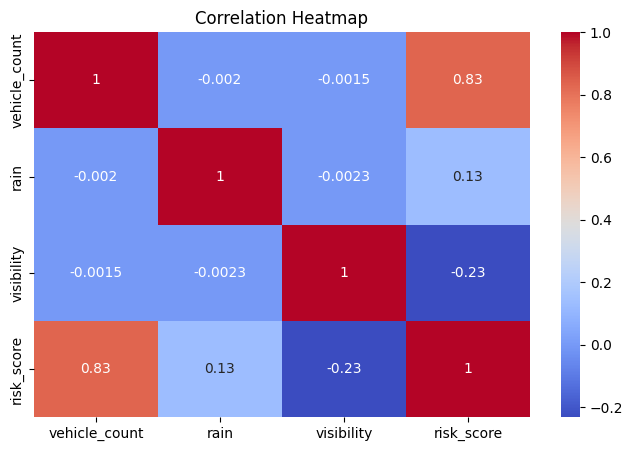

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['vehicle_count','rain','visibility','risk_score']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

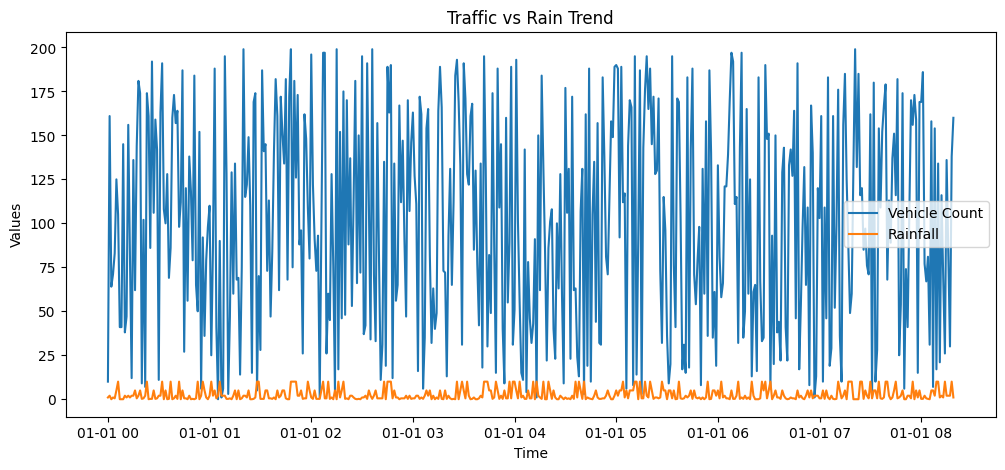

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'][:500], df['vehicle_count'][:500], label="Vehicle Count")
plt.plot(df['timestamp'][:500], df['rain'][:500], label="Rainfall")
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Traffic vs Rain Trend")
plt.legend()
plt.show()

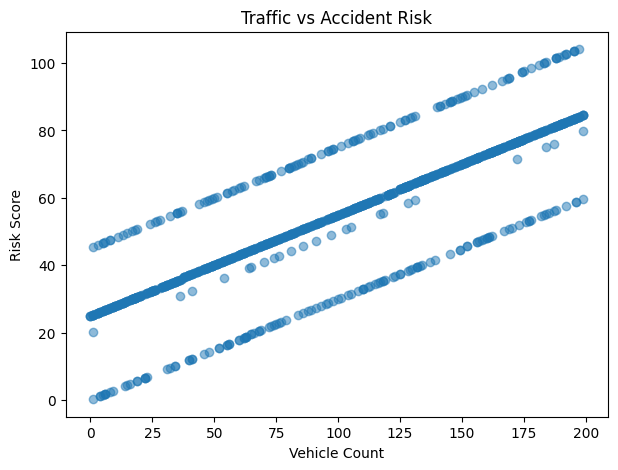

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df["vehicle_count"][:1000], df["risk_score"][:1000], alpha=0.5)
plt.xlabel("Vehicle Count")
plt.ylabel("Risk Score")
plt.title("Traffic vs Accident Risk")
plt.show()

In [14]:
def predict_accident_risk(vehicle_count, rain, visibility):
    risk = (vehicle_count * 0.3) + (rain * 25) + ((1 if visibility < 100 else 0) * 20)

    if risk > 60:
        return "HIGH RISK ⚠️"
    elif risk > 30:
        return "MEDIUM RISK ⚡"
    else:
        return "LOW RISK ✅"

print(predict_accident_risk(70, 1, 80))

HIGH RISK ⚠️


In [15]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17757, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 17757 (delta 73), reused 39 (delta 39), pack-reused 17639 (from 4)
Receiving objects: 100% (17757/17757), 17.15 MiB | 24.80 MiB/s, done.
Resolving deltas: 100% (12055/12055), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.1 MB/s eta 0:00:00


In [28]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Image Path:", image_path)

Saving Screenshot 2025-12-12 at 12.06.52 PM.jpg to Screenshot 2025-12-12 at 12.06.52 PM.jpg
Image Path: Screenshot 2025-12-12 at 12.06.52 PM.jpg


In [29]:
# Download pre-trained vehicle detector
!wget https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml

import cv2
import matplotlib.pyplot as plt

# Load classifier
car_cascade = cv2.CascadeClassifier('cars.xml')

--2025-12-12 06:37:52--  https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118803 (116K) [text/plain]
Saving to: ‘cars.xml.2’

cars.xml.2          100%[===================>] 116.02K  --.-KB/s    in 0.02s   

2025-12-12 06:37:52 (7.00 MB/s) - ‘cars.xml.2’ saved [118803/118803]



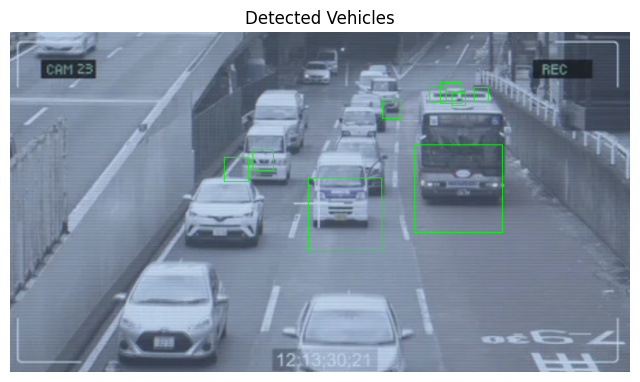

Vehicles detected: 9


In [30]:
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect vehicles
cars = car_cascade.detectMultiScale(gray, 1.2, 3)

# Draw boxes
for (x, y, w, h) in cars:
    cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)

# Show result
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Detected Vehicles")
plt.axis("off")
plt.show()

print("Vehicles detected:", len(cars))

In [31]:
vehicle_detected_from_cctv = 3

In [32]:
vehicles_detected = len(cars)
print("Vehicles detected from CCTV:", vehicles_detected)

Vehicles detected from CCTV: 9


In [33]:
df["cctv_detected"] = vehicles_detected

In [34]:
df["risk_score"] = (
    df["vehicle_count"] * 0.3 +
    df["is_rain"] * 25 +
    df["low_visibility"] * 20 +
    df["cctv_detected"] * 0.5
)

In [35]:
# After CCTV detection
vehicles_detected = len(cars)
print("Vehicles detected:", vehicles_detected)

# Add to dataframe
df["cctv_detected"] = vehicles_detected

# Recalculate risk score
df["risk_score"] = (
    df["vehicle_count"] * 0.3 +
    df["is_rain"] * 25 +
    df["low_visibility"] * 20 +
    df["cctv_detected"] * 0.5
)

df.head()

Vehicles detected: 9


,timestamp,vehicle_count,rain,visibility,is_rain,low_visibility,density_level,risk_score,cctv_detected
0,2025-01-01 00:00:00,10,1.0,474,1,0,Low,32.5,9
1,2025-01-01 00:01:00,161,2.0,319,1,0,High,77.8,9
2,2025-01-01 00:02:00,64,0.0,91,0,1,High,43.7,9
3,2025-01-01 00:03:00,71,1.0,289,1,0,High,50.8,9
4,2025-01-01 00:04:00,83,0.5,142,1,0,High,54.4,9


In [36]:
df["risk_score"] = (
    df["vehicle_count"] * 0.3 +
    df["is_rain"] * 25 +
    df["low_visibility"] * 20 +
    df["cctv_detected"] * 10
)

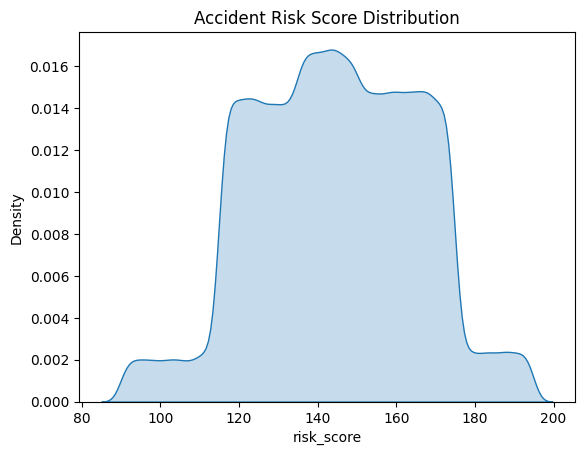

In [37]:
sns.kdeplot(df["risk_score"], fill=True)
plt.title("Accident Risk Score Distribution")
plt.show()

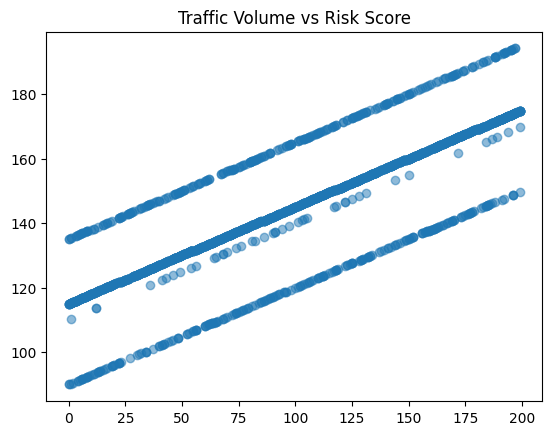

In [38]:
plt.scatter(df["vehicle_count"][:2000], df["risk_score"][:2000], alpha=0.5)
plt.title("Traffic Volume vs Risk Score")
plt.show()

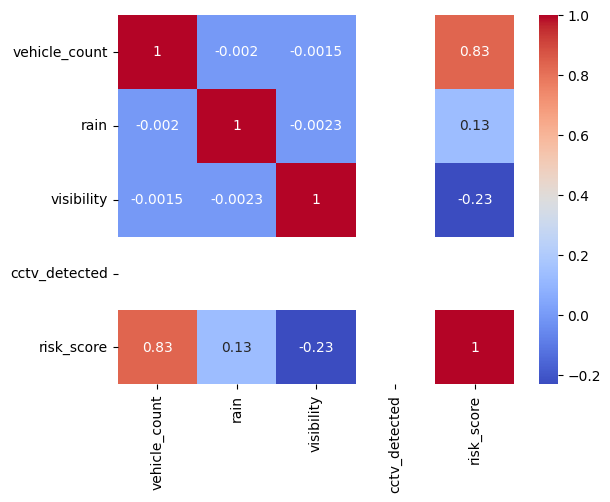

In [39]:
sns.heatmap(df[["vehicle_count","rain","visibility","cctv_detected","risk_score"]].corr(),
            annot=True, cmap="coolwarm")
plt.show()

In [40]:
df_final = df[["timestamp","vehicle_count","rain","visibility","cctv_detected","risk_score"]]
df_final.head(20)

,timestamp,vehicle_count,rain,visibility,cctv_detected,risk_score
0,2025-01-01 00:00:00,10,1.0,474,9,118.0
1,2025-01-01 00:01:00,161,2.0,319,9,163.3
2,2025-01-01 00:02:00,64,0.0,91,9,129.2
3,2025-01-01 00:03:00,71,1.0,289,9,136.3
4,2025-01-01 00:04:00,83,0.5,142,9,139.9
5,2025-01-01 00:05:00,125,5.0,227,9,152.5
6,2025-01-01 00:06:00,105,10.0,170,9,146.5
7,2025-01-01 00:07:00,41,0.0,417,9,102.3
8,2025-01-01 00:08:00,41,0.0,152,9,102.3
9,2025-01-01 00:09:00,145,0.0,434,9,133.5


In [41]:
def risk_label(score):
    if score > 60:
        return "High"
    elif score > 30:
        return "Medium"
    else:
        return "Low"

df["risk_label"] = df["risk_score"].apply(risk_label)
df[["risk_score","risk_label"]].head()

,risk_score,risk_label
0,118.0,High
1,163.3,High
2,129.2,High
3,136.3,High
4,139.9,High


In [42]:
features = df[["vehicle_count", "rain", "visibility", "cctv_detected"]]
labels = df["risk_label"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=120, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=120, random_state=42)

In [45]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00     60000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



In [47]:
def predict_risk_ml(vehicle_count, rain, visibility, cctv_detected):
    data = [[vehicle_count, rain, visibility, cctv_detected]]
    return model.predict(data)[0]

predict_risk_ml(80, 2, 90, 5)

'High'

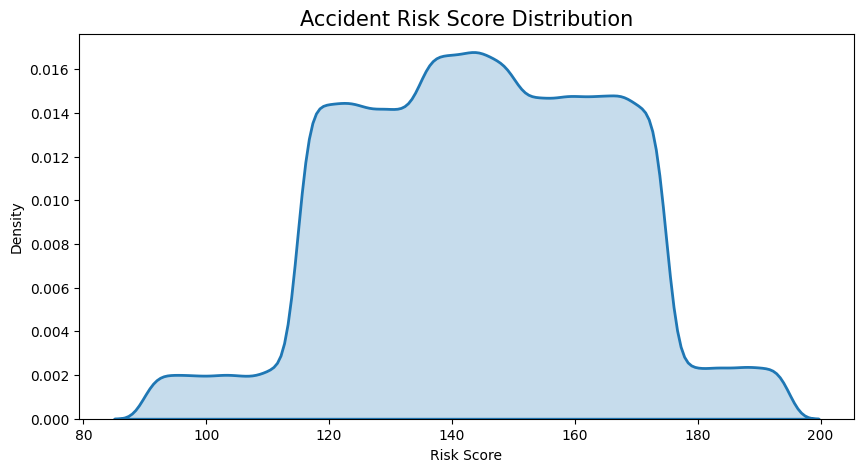

In [48]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["risk_score"], fill=True, linewidth=2)
plt.title("Accident Risk Score Distribution", fontsize=15)
plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.show()

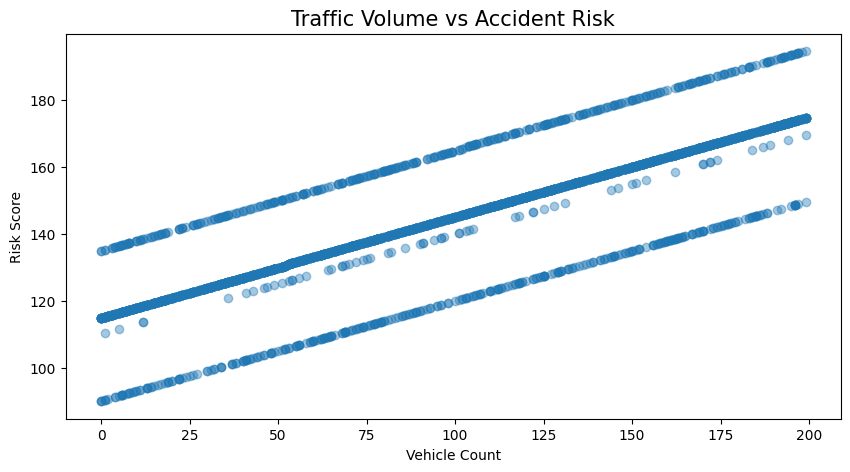

In [49]:
plt.figure(figsize=(10,5))
plt.scatter(df["vehicle_count"][:3000], df["risk_score"][:3000], alpha=0.4)
plt.title("Traffic Volume vs Accident Risk", fontsize=15)
plt.xlabel("Vehicle Count")
plt.ylabel("Risk Score")
plt.show()

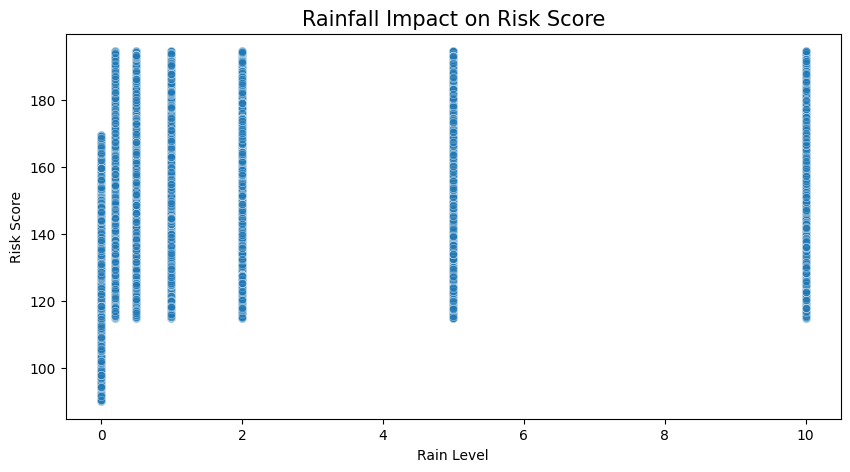

In [50]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df["rain"], y=df["risk_score"], alpha=0.5)
plt.title("Rainfall Impact on Risk Score", fontsize=15)
plt.xlabel("Rain Level")
plt.ylabel("Risk Score")
plt.show()

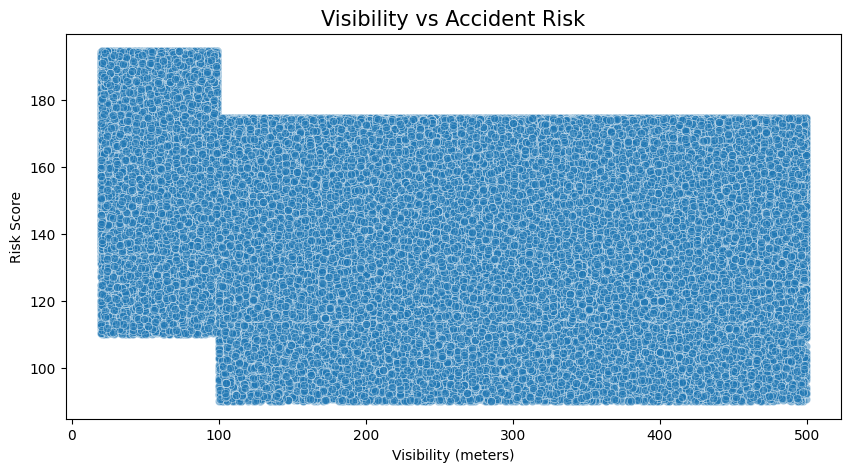

In [51]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df["visibility"], y=df["risk_score"], alpha=0.5)
plt.title("Visibility vs Accident Risk", fontsize=15)
plt.xlabel("Visibility (meters)")
plt.ylabel("Risk Score")
plt.show()

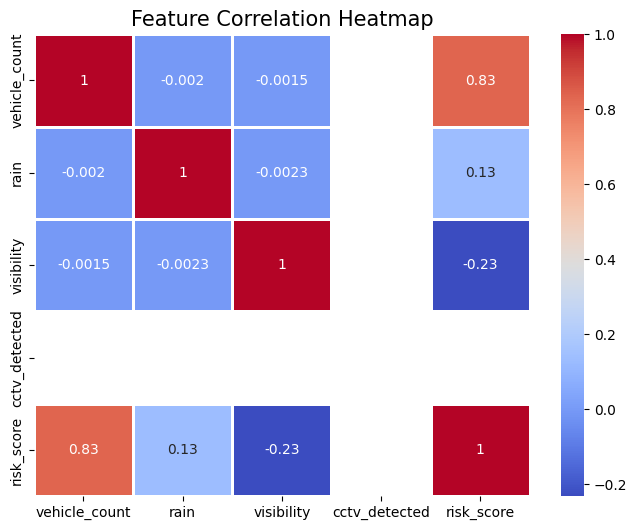

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["vehicle_count","rain","visibility","cctv_detected","risk_score"]].corr(),
            annot=True, cmap="coolwarm", linewidths=1)
plt.title("Feature Correlation Heatmap", fontsize=15)
plt.show()

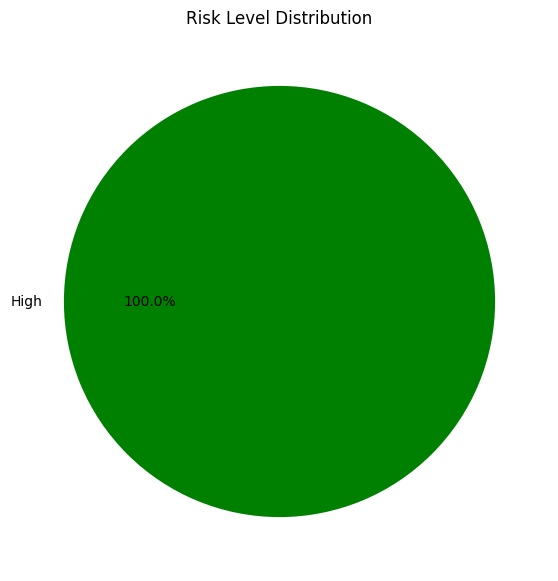

In [53]:
plt.figure(figsize=(7,7))
df["risk_label"].value_counts().plot.pie(autopct='%1.1f%%', colors=["green","orange","red"])
plt.title("Risk Level Distribution")
plt.ylabel("")
plt.show()

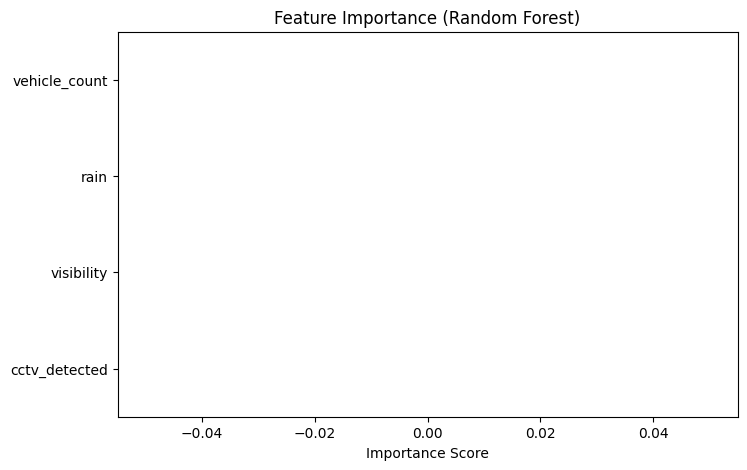

In [54]:
import numpy as np

feature_names = ["vehicle_count","rain","visibility","cctv_detected"]
importances = model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [58]:
def show_dashboard(df, model):
    # All 7 graphs together
    pass

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df["risk_label"] = df["risk_score"].apply(
    lambda x: "High" if x>60 else ("Medium" if x>30 else "Low")
)

features = df[["vehicle_count","rain","visibility","cctv_detected"]]
labels = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=120)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     60000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

